# Importing Dataset
The Red Wine Quality Dataset, available via the UCI Machine Learning Repository and Kaggle, contains 1,599 samples of Portuguese "Vinho Verde" red wine. It includes 11 physicochemical input features (e.g., acidity, pH, alcohol, density) and an ordinal output variable: quality (rated 0–10). The data is widely used for classification and regression to predict wine quality, often focusing on identifying key chemical properties. 

In [90]:
# Import pandas API
import pandas as pd

# Read the input csv file
dataset = pd.read_csv(r'C:\Users\Predator\Desktop\emlearn Examples\Dataset\winequality-red.csv')

# Display 10 random samples from the dataset
dataset.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
97,7.0,0.50,0.25,2.0,0.070,3.0,22.0,0.99630,3.25,0.63,9.2,5
505,10.2,0.49,0.63,2.9,0.072,10.0,26.0,0.99680,3.16,0.78,12.5,7
1142,6.9,0.45,0.11,2.4,0.043,6.0,12.0,0.99354,3.30,0.65,11.4,6
746,8.2,0.34,0.38,2.5,0.080,12.0,57.0,0.99780,3.30,0.47,9.0,6
1151,6.1,0.58,0.23,2.5,0.044,16.0,70.0,0.99352,3.46,0.65,12.5,6
1357,7.3,0.43,0.24,2.5,0.078,27.0,67.0,0.99648,3.60,0.59,11.1,6
961,7.1,0.56,0.14,1.6,0.078,7.0,18.0,0.99592,3.27,0.62,9.3,5
192,6.8,0.63,0.12,3.8,0.099,16.0,126.0,0.99690,3.28,0.61,9.5,5
271,11.5,0.18,0.51,4.0,0.104,4.0,23.0,0.99960,3.28,0.97,10.1,6
782,9.0,0.82,0.05,2.4,0.081,26.0,96.0,0.99814,3.36,0.53,10.0,5


# Splitting the Feature Variables and Target Variable
Based on the standard "White Wine Quality" dataset (commonly found in the UCI Machine Learning Repository), the dataset consists of 11 physicochemical input variables as features and a whine quality score variable as target.
* Target Variable (quality): The wine quality score rating, typically ranging from 0 to 10.
* Features Varaible: 11 physicochemical variables such as fixed acidity, volatile acidity, ..., and alcohol

In [91]:
# Separate the features variables from the target variable
X = dataset.drop(['quality'], axis=1)

# Display 10 random samples of features
X.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1090,10.0,0.260,0.54,1.9,0.083,42.0,74.0,0.99451,2.98,0.63,11.8
56,10.2,0.420,0.57,3.4,0.070,4.0,10.0,0.99710,3.04,0.63,9.6
799,9.4,0.500,0.34,3.6,0.082,5.0,14.0,0.99870,3.29,0.52,10.7
1563,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1
221,7.4,0.530,0.26,2.0,0.101,16.0,72.0,0.99570,3.15,0.57,9.4
1045,6.9,0.440,0.00,1.4,0.070,32.0,38.0,0.99438,3.32,0.58,11.4
491,9.2,0.410,0.50,2.5,0.055,12.0,25.0,0.99520,3.34,0.79,13.3
592,9.0,0.450,0.49,2.6,0.084,21.0,75.0,0.99870,3.35,0.57,9.7
887,10.7,0.520,0.38,2.6,0.066,29.0,56.0,0.99577,3.15,0.79,12.1
1426,7.7,0.230,0.37,1.8,0.046,23.0,60.0,0.99710,3.41,0.71,12.1


In [92]:
# Separate the target variable
y = dataset['quality']

# Display 10 random samples of target variable
y.sample(10)

1532    6
498     8
962     5
1124    4
392     5
728     5
1393    5
413     7
138     5
788     6
Name: quality, dtype: int64

# Visualaszing Features and Target Variables Correlation
Understanding the relationship between the physicochemical features and the target variable (`quality`) is crucial for regression analysis. Visualizing these correlations helps identify which features are most influential in predicting wine quality.

Common visualization technique is scatter plots with regression lines show how individual features relate to quality. The `regplot` in the Seaborn library is a linear model plot used for visualizing the linear relationship between two continuous variables in the data. It plots a scatter plot of data points and a fitted linear regression line with a 95% confidence interval. It is essential for visualizing the trend and relationship between two continuous variables.

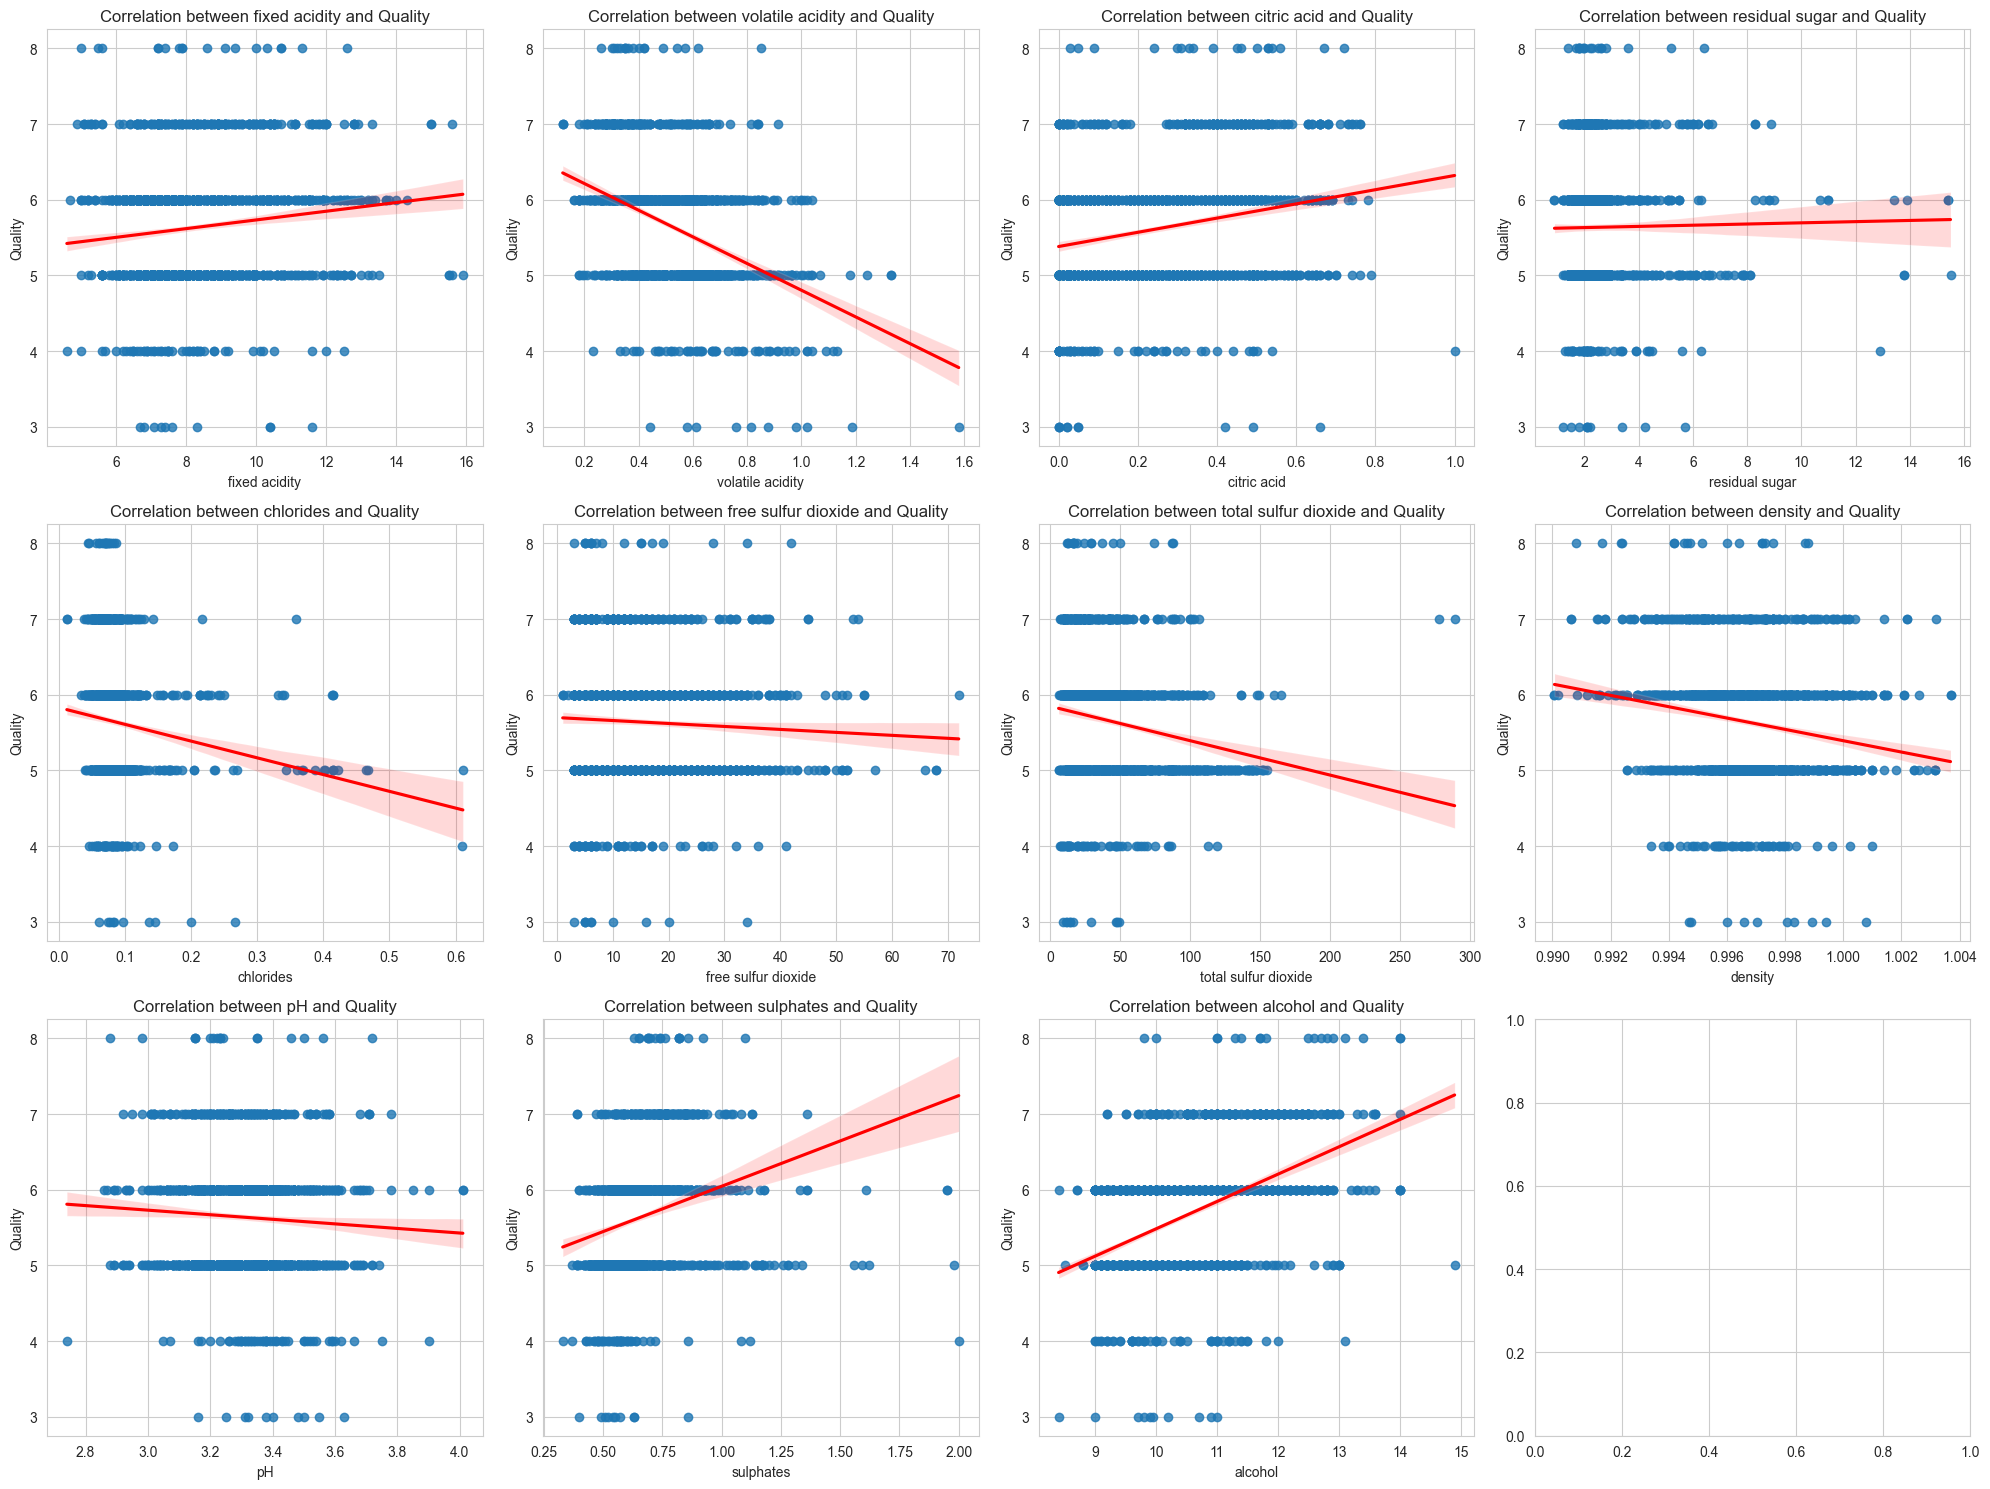

In [93]:
# Visualize the correlation between the features and the target variable
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style of the plots
sns.set_style('whitegrid')

# Create a subplot grid
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# Loop through each feature and create a scatter plot with a regression line
for i, feature in enumerate(X.columns):
    row = i // 4    # Determine the row index
    col = i % 4     # Determine the column index

    # Create a scatter plot with a regression line for the current feature against the target variable
    sns.regplot(
        x=feature,
        y='quality',
        data=dataset,
        ax=axes[row, col],
        line_kws={"color": "red"}
    )

    # Set the title and labels for the current subplot
    axes[row, col].set_title(f'Correlation between {feature} and Quality')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Quality')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

## Dataset Features Analysis
Dataset feature analysis for regression involves selecting relevant, numerical input variables $X$ to predict a continuous target $y$. Key steps include analyzing feature-target correlations, removing multicollinearity between predictors, handling outliers, and ensuring data linearity. Techniques include feature selection, correlation matrices, and visualization.

The most common method is the **Pearson correlation coefficient**, which measures the linear relationship between numerical variables. The correlation coefficients range from $-1$ to $1$.
$$
r = \frac{\sum_{i=1}^n (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^n (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^n (Y_i - \bar{Y})^2}}
$$
Where:
- $X_i$, $Y_i$ are the individual sample points
- $\bar{X}$, $\bar{Y}$ are the means of $X$ and $Y$
- $n$ is the number of samples

Interpretation:
* **Values near 1**: Strong positive linear correlation (as one variable increases, the other tends to increase).
* **Values near -1**: Strong negative linear correlation (as one variable increases, the other tends to decrease).
* **Values near 0**: No significant linear correlation. 

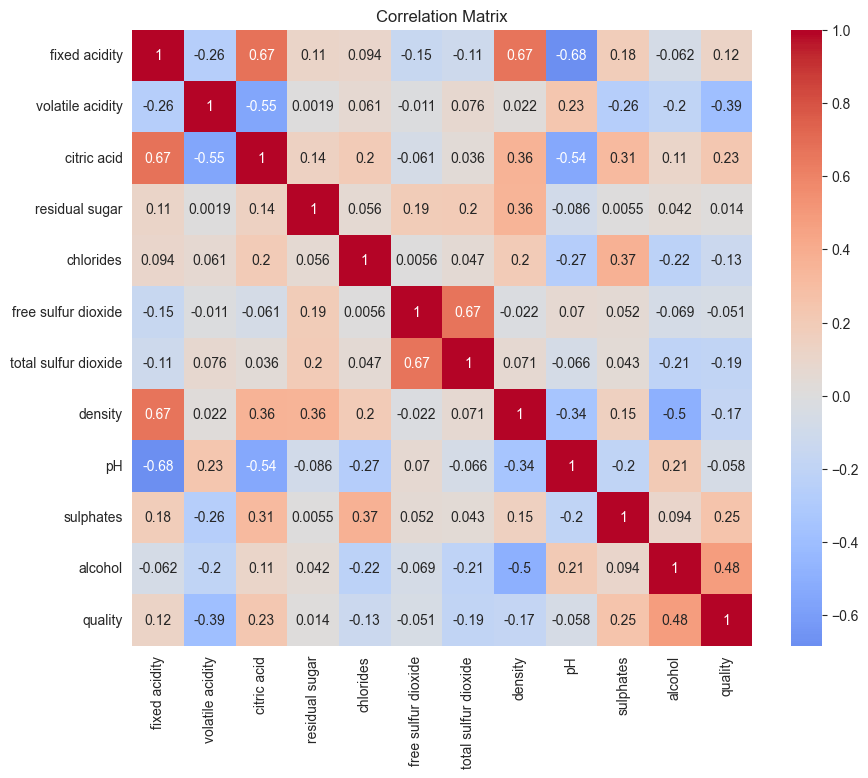

In [94]:
# Import seaborn and matplotlib for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix using Pearson's method
correlation_matrix = dataset.corr(method='pearson')

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [95]:
# Create a dataframe to display the correlation values of each feature with the target variable 'quality'
correlation_matrix_df = pd.DataFrame({'Wine Features': correlation_matrix.index, 
                                      'Correlation with Quality': correlation_matrix['quality']})

# Display the correlation values sorted in descending order
correlation_matrix_df.style.hide(axis='index')

Wine Features,Correlation with Quality
fixed acidity,0.124052
volatile acidity,-0.390558
citric acid,0.226373
residual sugar,0.013732
chlorides,-0.128907
free sulfur dioxide,-0.050656
total sulfur dioxide,-0.185100
density,-0.174919
pH,-0.057731
sulphates,0.251397


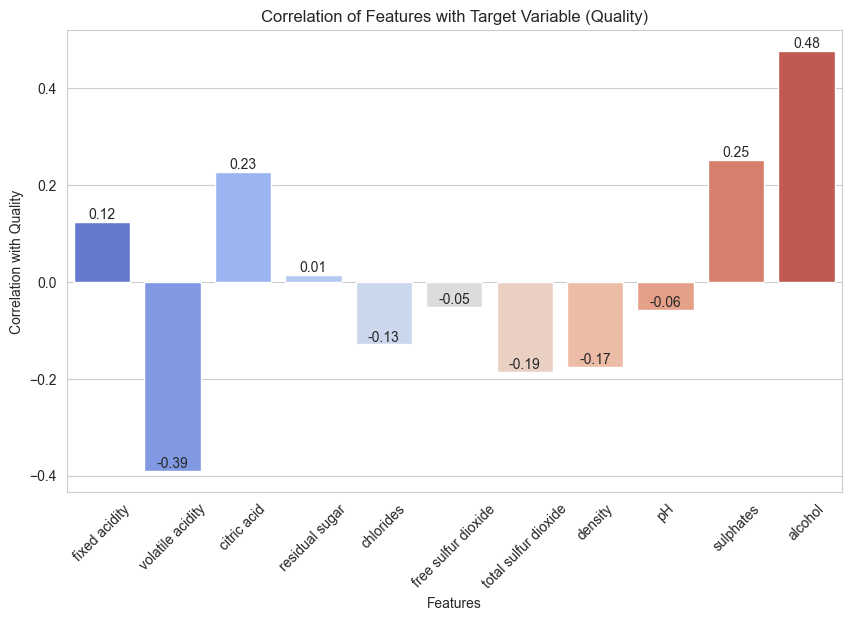

In [96]:
# Plot the correlation score of each feature with the target variable using a bar plot
plt.figure(figsize=(10, 6))

# Extract the correlation of each feature with the target variable
features_corr_with_target = dataset.corr(method='pearson')['quality'].drop('quality')

# Create a bar plot of the correlation scores with the target variable each bar has a score value on top of it
sns.barplot(x=features_corr_with_target.index, 
            y=features_corr_with_target.values, 
            hue=features_corr_with_target.index, 
            palette='coolwarm', 
            legend=False)

plt.title('Correlation of Features with Target Variable (Quality)')
plt.xlabel('Features')
plt.ylabel('Correlation with Quality')
plt.xticks(rotation=45)
# Add correlation score values on top of each bar
for index, value in enumerate(features_corr_with_target.values):
    plt.text(index, value, f'{value:.2f}', ha='center', va='bottom')
plt.show()

# Features Selection

Feature selection for regression optimizes model performance and interpretability by selecting relevant, non-redundant input variables (predictors) to predict a continuous target. It helps reduce overfitting, improve accuracy, and decrease training time.

### Common Feature Selection Methods

- **SelectKBest**: Selects the top $k$ features based on a scoring function. For regression, common scoring functions includes **ANOVA F-value** (`f_regression`) that measures the linear dependency between each feature and the target variable.
- **SelectPercentile**: Selects a user-specified top percentage of features based on a scoring function (e.g., top 20% most correlated features).

These methods help identify the most informative features, leading to simpler and more robust models.

In [97]:
# Features selection using SelectKBest with f_regression method
from sklearn.feature_selection import SelectKBest, f_regression

# Initialize the feature selector
selector = SelectKBest(score_func=f_regression, k=7)  # Select top 7 features

# Fit the selector on the training data
selector.fit_transform(X, y)

# Transform the test data using the same selector
X_selected = selector.transform(X)

# Display the top 7 features selected by SelectKBest with score values
selected_features = X.columns[selector.get_support()]
feature_scores = selector.scores_[selector.get_support()]

# Create a dataframe to display the selected features and their scores
selected_features_df = pd.DataFrame({'Selected Features': selected_features.str.capitalize(), 'Feature Scores': feature_scores})

# Sort dataframe by feature scores in descending order
selected_features_df = selected_features_df.sort_values(by='Feature Scores', ascending=False)

# Display the selected features and their scores
selected_features_df.style.hide(axis='index')

Selected Features,Feature Scores
Alcohol,468.267011
Volatile acidity,287.444450
Sulphates,107.740433
Citric acid,86.257726
Total sulfur dioxide,56.657818
Density,50.405223
Chlorides,26.985608


In [98]:
# Features selection using SelectPercentile with f_regression method
from sklearn.feature_selection import SelectPercentile, f_regression

# Initialize the feature selector
selector_percentile = SelectPercentile(score_func=f_regression, percentile=70)  # Select top 70% features

# Fit the selector on the training data
selector_percentile.fit_transform(X, y)

# Transform the test data using the same selector
X_selected_percentile = selector_percentile.transform(X)

# Display the features selected by SelectPercentile with score values
selected_features_percentile = X.columns[selector_percentile.get_support()]
feature_scores_percentile = selector_percentile.scores_[selector_percentile.get_support()]

# Create a dataframe to display the selected features and their scores
selected_features_percentile_df = pd.DataFrame({'Selected Features': selected_features_percentile.str.capitalize(), 
                                                'Feature Scores': feature_scores_percentile})

# Sort dataframe by feature scores in descending order
selected_features_percentile_df = selected_features_percentile_df.sort_values(by='Feature Scores', ascending=False)

# Display the selected features and their scores
selected_features_percentile_df.style.hide(axis='index')

Selected Features,Feature Scores
Alcohol,468.267011
Volatile acidity,287.444450
Sulphates,107.740433
Citric acid,86.257726
Total sulfur dioxide,56.657818
Density,50.405223
Chlorides,26.985608


In [101]:
# Create a dataframe consist to selected features and target variable
selected_features_df = pd.DataFrame(X_selected, columns=selected_features.str.capitalize())

# Display the random 5 rows of the dataframe with selected features and target variable
selected_features_df.sample(5).style.hide(axis='index').set_properties(**{'text-align': 'center'})

Volatile acidity,Citric acid,Chlorides,Total sulfur dioxide,Density,Sulphates,Alcohol
0.660000,0.220000,0.069000,23.000000,0.996800,1.200000,10.300000
0.310000,0.570000,0.111000,85.000000,0.997100,0.530000,9.700000
0.520000,0.380000,0.096000,18.000000,0.996660,0.520000,9.400000
0.490000,0.280000,0.110000,136.000000,0.997200,1.950000,9.900000
0.340000,0.450000,0.082000,15.000000,0.998800,0.660000,9.200000


# Dataset Preprocessing
### Normalizing the Features Data
A **Robust Scaler** is a data preprocessing technique designed to scale features in a dataset while minimizing the influence of outliers. Unlike `StandardScaler` technique that use the mean and variance which are heavily influenced by extreme values, the Robust Scaler uses the median and the **Interquartile Range** (IQR). The `MinMaxScaler`, which crushes data into 0 to 1 range based on extreme minimum and maximum values, the RobustScaler ensures that inliers retain their relative relationships and distribution shape.

For a given data point $X$, the Min-Max scaled value $X_{scaled}$ is calculated as: 
$$
X_{scaled}=\frac{X-median(X)}{IQR}
$$

$ Where: $

$$
IQR=Q_{3}(X)-Q_{1}(X)
$$

In [102]:
# Scale the dataset using RobustScaler
from sklearn.preprocessing import RobustScaler

# Create an instance of the RobustScaler
scaler = RobustScaler()

# Fit the scaler to the features and transform them
X_scaled = scaler.fit_transform(selected_features_df)

# Create a dataframe for the scaled features with the same column names as the selected features
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features_df.columns)

# Display some random samples of the scaled features
X_scaled_df.sample(10).style.hide(axis='index').set_properties(**{'text-align': 'center'}) 

Volatile acidity,Citric acid,Chlorides,Total sulfur dioxide,Density,Sulphates,Alcohol
-0.840000,0.696970,-0.800000,0.050000,0.380313,-0.611111,-0.250000
-0.800000,0.545455,-0.900000,-0.100000,-0.854586,1.000000,0.875000
0.080000,0.000000,0.900000,-0.175000,0.380313,-0.111111,-0.562500
-0.080000,-0.515152,1.800000,0.100000,0.156600,0.000000,-0.437500
-0.280000,0.696970,-0.200000,-0.800000,0.067114,0.055556,0.125000
0.660000,1.515152,1.050000,0.125000,2.885906,0.333333,0.625000
-0.800000,0.909091,-0.300000,-0.750000,-0.630872,0.611111,0.750000
0.200000,0.060606,-1.550000,0.275000,-1.346756,-0.111111,1.625000
0.360000,-0.212121,0.750000,0.775000,0.501119,-0.666667,-0.125000
0.980000,-0.121212,-0.750000,0.100000,-0.201342,-0.388889,-0.500000


# Splitting the Dataset into Training, Testing, and Validation Set
Splitting a dataset is a crucial step in machine learning to evaluate model performance and prevent overfitting. Typically, the data is divided into three sets:
- **Training Set**: Used to train the model.
- **Testing Set**: Used to assess the final model performance.

A common approach is to split the dataset into training and testing sets.

<img src="https://cdn.imweb.me/upload/S202105076e626e4618b27/0f0c2df8f341c.png">

In [104]:
# Include Train test set split function from scikit-learn
from sklearn.model_selection import train_test_split

# Split data set to training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, 
                                                    y, 
                                                    test_size=0.20, 
                                                    shuffle=True, 
                                                    random_state=43, 
                                                    stratify=y)

# Split the training set for validation (20% of training set) and training (80% of training set)
X_null, X_val, y_null, y_val = train_test_split(X_train, 
                                                y_train,
                                                test_size=0.20,
                                                shuffle=True,
                                                random_state=43,
                                                stratify=y_train)

# Create a dataframe that holds the dataset shape (number of samples and features) for training and testing sets
dataset_shape = pd.DataFrame({
    'Dataset': ['Dataset', 'Training Set', 'Testing Set', 'Validation Set'],
    'Samples': [X_scaled.shape[0], X_train.shape[0], X_test.shape[0], X_val.shape[0]],
    'Features': [X_scaled.shape[1], X_train.shape[1], X_test.shape[1], X_val.shape[1]],
    'Targets': [y.shape[0], y_train.shape[0], y_test.shape[0], y_val.shape[0]]
})

# Display the training and test set shapes
dataset_shape.style.hide(axis='index')

Dataset,Samples,Features,Targets
Dataset,1599,7,1599
Training Set,1279,7,1279
Testing Set,320,7,320
Validation Set,256,7,256


# Training a Tree-Based Regression Models


In [105]:
# Import MLP Regressor algorithm from scikit-learn
from sklearn.neural_network import MLPRegressor

# Initialize the MLP Regressor with specified parameters
mlp_regressor = MLPRegressor(hidden_layer_sizes=(64, 32, 8), 
                             activation='relu', 
                             solver='adam', 
                             max_iter=500, 
                             random_state=42)

# Fit the regressor to the training data
mlp_regressor.fit(X_train, y_train)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [107]:
# Import Keras API
from keras.models import Sequential
from keras.layers import Dense, Input

# Create a sequential model
model = Sequential()

# Add input layer as the first layer
model.add(Input(shape=(X_train.shape[1],)))
# Add first hidden layer with 64 neurons and relu activation function
model.add(Dense(units=64, activation='relu'))
# Add second hidden layer with 32 neurons and relu activation function
model.add(Dense(units=32, activation='relu'))
# Add third hidden layer with 8 neurons and relu activation function
model.add(Dense(units=8, activation='relu'))
# Add output layer with 1 neuron and linear activation function for regression
model.add(Dense(units=1, activation='linear'))

# Compile the model with mean squared error loss and adam optimizer
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error', 'mean_squared_error'])

# Train the model on the training data
history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 30.8369 - mean_absolute_error: 5.4898 - mean_squared_error: 30.8369 - val_loss: 27.3154 - val_mean_absolute_error: 5.1416 - val_mean_squared_error: 27.3154
Epoch 2/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21.0500 - mean_absolute_error: 4.4442 - mean_squared_error: 21.0500 - val_loss: 13.9816 - val_mean_absolute_error: 3.4791 - val_mean_squared_error: 13.9816
Epoch 3/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.5000 - mean_absolute_error: 2.2806 - mean_squared_error: 7.5000 - val_loss: 5.3199 - val_mean_absolute_error: 1.7727 - val_mean_squared_error: 5.3199
Epoch 4/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1440 - mean_absolute_error: 1.4182 - mean_squared_error: 3.1440 - val_loss: 2.7413 - val_mean_absolute_error: 1.3260 - val_mean_squared_error: 2.7413
Epoch 5/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0341 - mean_absolute_error: 1.1416 - mean_squared_error: 2.0341 - val_loss: 1.8087 - va

# Test Prediction for Trained Regression Model
After training a regression model, it is important to evaluate its performance on unseen data. This is typically done by making predictions on the test set and comparing them to the actual target values.

**Key Steps:**
- Use the trained regression model to predict target values for the test set features.
- Compare the predicted values with the actual test set targets.
- Analyze the prediction errors to assess model performance.

**Purpose:**
- To estimate how well the model generalizes to new, unseen data.
- To identify potential issues such as overfitting or underfitting.

**Common Practices:**
- Display a few random test samples with their actual and predicted values.
- Calculate and report error metrics (e.g., MAE, MSE, RMSE, $R^2$) for the test set.

This process provides a realistic measure of the model's predictive power and helps guide further model improvement.

In [128]:
# Select a random sample of test features for predection
import random as round

# Generate random indices for selecting test samples
random_indices = round.sample(range(X_test.shape[0]), 1)

# Select the random samples from the test set
X_test_sample = X_test[random_indices]
y_test_sample = y_test.iloc[random_indices]

# Inverse transform the scaled data back to original form
X_test_sample_raw = scaler.inverse_transform(X_test_sample)

# Create a dataframe for raw and scaled test features
X_test_sample_df = pd.DataFrame({
    'Raw Test Features': [pd.DataFrame(scaler.inverse_transform(X_test_sample)).to_csv(header=False, index=False).strip()],
    'Scaled Test Features': [pd.DataFrame(X_test_sample).to_csv(header=False, index=False).strip()],
    'Target Value': [y_test_sample.values[0]]
})

# Limit the dataframe decimal point to 6 places for better readability
X_test_sample_df['Scaled Test Features'] = X_test_sample_df['Scaled Test Features'].apply(lambda x: '\n'.join([','.join([f'{float(value):.6f}' 
                                                                        for value in row.split(',')]) 
                                                                        for row in x.split('\n')]))

# Display the raw and scaled test features along with their corresponding trget values
X_test_sample_df.style.hide(axis='index').set_properties(**{'text-align': 'center'})

Raw Test Features,Scaled Test Features,Target Value
"0.585,0.0,0.044,86.0,0.99264,0.94,12.9","0.260000,-0.787879,-1.750000,1.200000,-1.838926,1.777778,1.687500",7


In [129]:
# Do predictions using the trained MLP Regressor on the selected random test sample
mlp_pred = mlp_regressor.predict(X_test_sample).flatten()

# Do predictions using the trained Keras Neural Network Regressor on the selected random test sample
keras_pred = model.predict(X_test_sample, verbose=0).flatten()

# Comput for the absolute error for a single sample
mlp_abs_err = abs(y_test_sample.values[0] - mlp_pred[0])
keras_abs_err = abs(y_test_sample.values[0] - keras_pred[0])

# Create a dataframe to display the predictions and their corresponding errors for both models
predictions_df = pd.DataFrame({
    'Model': ['MLP Regressor', 'Keras Regressor'],
    'Predicted Value': [mlp_pred[0], keras_pred[0]],
    'Actual Value': [y_test_sample.values[0], y_test_sample.values[0]],
    'Absolute Error': [mlp_abs_err, keras_abs_err]
})

# Display the predictions and their corresponding errors for both models
predictions_df.style.hide(axis='index')

Model,Predicted Value,Actual Value,Absolute Error
MLP Regressor,7.086804,7,0.086804
Keras Regressor,7.217745,7,0.217745


### Performance Metrics
Tree-based regression models should be evaluated on a held-out test set rather than on the training data alone.

In this section, the models are compared using four standard regression metrics:
- **MAE (Mean Absolute Error):** average absolute prediction error. Lower is better.
- **MSE (Mean Squared Error):** average squared prediction error. Lower is better.
- **RMSE (Root Mean Squared Error):** square root of MSE, expressed in the target variable's units. Lower is better.
- **$R²$ Score:** proportion of variance explained by the model. Higher is better, with `1.0` being a perfect fit.

In [116]:
# Import evaluation metrics from scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Create fresh models for a fair evaluation on the held-out test set
evaluation_models = {
    'MLP Regressor': mlp_regressor,
    'Keras Regressor': model
}

# Evaluate each model and store the results in a list of dictionaries
evaluation_rows = []

# Fit each model, make predictions, and calculate evaluation metrics
for model_name, model in evaluation_models.items():
    model.fit(X_test, y_test)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    evaluation_rows.append({
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R^2 Score': r2,
    })

# Create a DataFrame from the evaluation results and sort by Model
metrics_df = pd.DataFrame(evaluation_rows).sort_values(by='Model').reset_index(drop=True)

# Display the evaluation metrics DataFrame
metrics_df.style.hide(axis='index').set_properties(**{'text-align': 'center'})

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5446 - mean_absolute_error: 0.5478 - mean_squared_error: 0.5446 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


c:\Users\Predator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Model,MAE,MSE,RMSE,R^2 Score
Keras Regressor,0.505418,0.453195,0.673198,0.297669
MLP Regressor,0.327032,0.190783,0.436787,0.704337


Interpretation of the metrics table:

- Lower **MAE**, **MSE**, and **RMSE** values indicate better predictive accuracy.
- Higher **$R²$ Score** indicates that the model explains more of the variation in wine quality.
- The best model is typically the one with the **lowest RMSE** and a **high $R²$ Score** on the test set, because this reflects better generalization to unseen data.

## Regression Visualization: Q-Q Plot

Visualizing regression results is crucial for understanding model performance and diagnosing potential issues. Two common visualization techniques are Q-Q plots and regplots:

### Q-Q Plot (Quantile-Quantile Plot)
A Q-Q Plot is a scatterplot comparing theoretical normal distribution quantiles against observed regression residual quantiles to evaluate model fit. If residuals are normally distributed—a key assumption for linear regression inference—data points will fall approximately along a straight 45-degree reference line.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


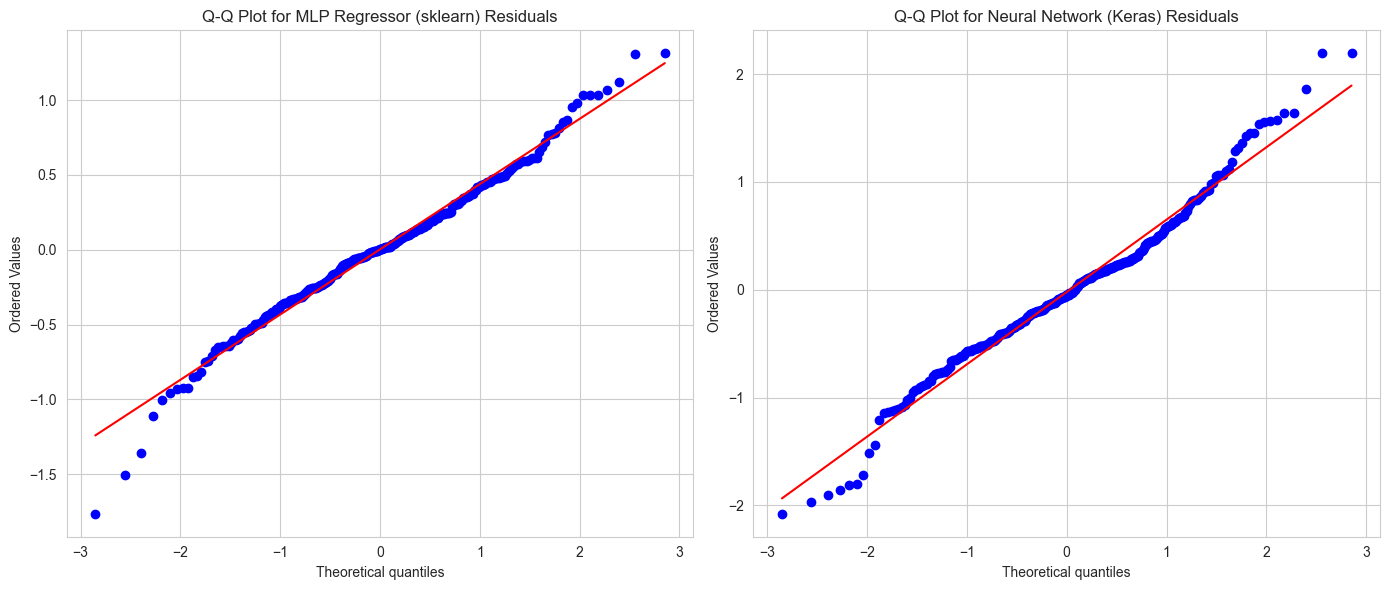

In [117]:
# Plot the Q-Q plot for the predictions of each model
import scipy.stats as stats

# Define the evaluation models
evaluation_models = {
    'MLP Regressor (sklearn)': mlp_regressor,
    'Neural Network (Keras)': model,
}

# Create a subplot grid for Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loop through each model and create a Q-Q plot of the predictions
for i, (model_name, eval_model) in enumerate(evaluation_models.items()):
    predictions = eval_model.predict(X_test).flatten()
    residuals = y_test - predictions

    # Create a Q-Q plot for the residuals
    stats.probplot(residuals, dist="norm", plot=axes[i])

    # Set the title for the current subplot
    axes[i].set_title(f'Q-Q Plot for {model_name} Residuals')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

## Interpretation of the Q-Q Plots

A Q-Q plot compares the distribution of model residuals against a theoretical normal distribution. If the residuals lie close to the reference line, the errors are approximately normal. Large deviations from the line indicate non-normality, skewness, heavy tails, or discrete prediction behavior.

# Port the Classifier Model to C Code
## emlearn - Machine Learning for Tiny Embedded Systems
```emlearn``` is an open-source Python library that allows converting scikit-learn and Keras models to efficient C code. This makes it easy to deploy to any microcontroller with, while keeping Python-based workflow that is familiar to Machine Learning Engineers.

To install emlearn to convert models in Python, use ```pip install emlearn```

In [118]:
# Convert model using emlearn
import emlearn

# Convert the trained MLP Regressor to C++ code using emlearn
mlp_regressor_c_model = emlearn.convert(mlp_regressor, method='loadable', dtype='float', return_type='regressor')

# Generate and save the C code to a header file
mlp_regressor_c_code = mlp_regressor_c_model.save(file='MLPRegressor.h', name='MLPRegressor')

# Print the generated C code for the MLP Regressor
print(mlp_regressor_c_code)


#include <eml_net.h>
static const float MLPRegressor_layer_0_biases[64] = { 0.057887f, -0.186753f, 0.142817f, 0.142455f, -0.091008f, 0.373664f, -0.142008f, 0.109075f, -0.196870f, 0.140561f, -0.174443f, -0.133355f, -0.258612f, 0.199738f, 0.210406f, 0.150152f, 0.425495f, 0.041628f, -0.103791f, 0.338859f, -0.107485f, 0.400860f, -0.182852f, 0.237891f, -0.335612f, 0.341052f, 0.136870f, 0.405289f, -0.178496f, 0.151771f, 0.368076f, 0.098825f, 0.160955f, 0.205376f, 0.046188f, 0.220422f, 0.131308f, 0.317945f, -0.073598f, -0.150401f, 0.245700f, 0.362871f, -0.031519f, 0.107230f, -0.093533f, -0.096186f, 0.088499f, -0.003159f, 0.154657f, -0.261518f, 0.407466f, 0.338796f, 0.167373f, 0.105940f, -0.050447f, 0.130727f, 0.092234f, -0.206800f, 0.402126f, 0.308263f, 0.371684f, 0.235531f, 0.172724f, -0.096042f };
static const float MLPRegressor_layer_0_weights[448] = { -0.097982f, 0.324656f, 0.094351f, 0.072857f, -0.078380f, -0.172167f, -0.357894f, 0.300435f, 0.087838f, -0.063830f, -0.412365f, 0.302242f, 

In [119]:
# Convert the trained MLP Regressor to C++ code using emlearn
dnn_regressor_c_model = emlearn.convert(model, method='loadable', dtype='float', return_type='regressor')

# Generate and save the C code to a header file
dnn_regressor_c_code = dnn_regressor_c_model.save(file='NeuralNetworkRegressor.h', name='NeuralNetworkRegressor')

# Print the generated C code for the Neural Network Regressor
print(dnn_regressor_c_code)


#include <eml_net.h>
static const float NeuralNetworkRegressor_layer_0_biases[64] = { -0.264812f, 0.350621f, 0.226604f, 0.045277f, -0.061982f, -0.246676f, 0.103847f, 0.138922f, -0.271513f, 0.239081f, 0.099875f, 0.205165f, 0.417879f, 0.316101f, 0.006644f, -0.076712f, 0.206478f, -0.031959f, -0.139515f, -0.238301f, 0.319945f, -0.284774f, 0.307989f, 0.206970f, 0.460243f, 0.187504f, 0.381249f, 0.163301f, 0.273381f, 0.301634f, 0.063829f, 0.312070f, 0.209265f, 0.112919f, 0.185219f, 0.197518f, 0.126402f, 0.297659f, 0.125557f, 0.257230f, 0.338283f, 0.388090f, 0.340169f, 0.161699f, 0.193360f, 0.018778f, 0.150133f, 0.042432f, 0.209237f, 0.173608f, 0.259065f, -0.041003f, 0.226181f, 0.197628f, 0.170842f, -0.220602f, 0.132476f, 0.315916f, 0.040265f, 0.229817f, 0.134942f, 0.177282f, 0.296292f, 0.116235f };
static const float NeuralNetworkRegressor_layer_0_weights[448] = { -0.181150f, 0.165297f, -0.107244f, -0.572509f, 0.030943f, 0.403266f, -0.189132f, -0.222413f, 0.353212f, -0.180102f, -0.214268f, -